In [ ]:
import l0mdt_gnn
import numpy as np
import torch

/home/dhumphreys/L0MDT/l0mdt_gnn/.venv/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
graphBuilder = l0mdt_gnn.graphBuilder(multilayer_scaler = 51)
station_0_inputs = dict(np.load("/data/dhumphreys/L0MDT/data_NGT/samples/npy/station_0_inputs.npz", allow_pickle=True))
station_2_inputs = dict(np.load("/data/dhumphreys/L0MDT/data_NGT/samples/npy/station_2_inputs.npz", allow_pickle=True))
station_4_inputs = dict(np.load("/data/dhumphreys/L0MDT/data_NGT/samples/npy/station_4_inputs.npz", allow_pickle=True))

In [3]:
events_station_0 = l0mdt_gnn.makeEvents(station_0_inputs)
events_station_2 = l0mdt_gnn.makeEvents(station_2_inputs)
events_station_4 = l0mdt_gnn.makeEvents(station_4_inputs)

In [4]:
graphs_station_0, event_ids_station_0 = l0mdt_gnn.getGraphs(events_station_0, graphBuilder)
graphs_station_2, event_ids_station_2 = l0mdt_gnn.getGraphs(events_station_2, graphBuilder)
graphs_station_4, event_ids_station_4 = l0mdt_gnn.getGraphs(events_station_4, graphBuilder)

In [5]:
torch.save(graphs_station_0, '/data/dhumphreys/L0MDT/data_NGT/samples/graphs/graphs_station_0.pt')
np.save('/data/dhumphreys/L0MDT/data_NGT/samples/graphs/event_ids_station_0.npy', event_ids_station_0)
torch.save(graphs_station_2, '/data/dhumphreys/L0MDT/data_NGT/samples/graphs/graphs_station_2.pt')
np.save('/data/dhumphreys/L0MDT/data_NGT/samples/graphs/event_ids_station_2.npy', event_ids_station_2)
torch.save(graphs_station_4, '/data/dhumphreys/L0MDT/data_NGT/samples/graphs/graphs_station_4.pt')
np.save('/data/dhumphreys/L0MDT/data_NGT/samples/graphs/event_ids_station_4.npy', event_ids_station_4)

In [8]:
import matplotlib.pyplot as plt

def plot_event_graph(data):
    # Extract node coordinates
    tube_number = data.x[:, 0].numpy()
    tube_layer  = data.x[:, 1].numpy()

    # Extract edges
    src, dst = data.edge_index.numpy()

    plt.figure(figsize=(12, 6))

    # Draw edges
    for s, d in zip(src, dst):
        plt.plot(
            [tube_number[s], tube_number[d]],
            [tube_layer[s], tube_layer[d]],
            color='gray', alpha=0.4, linewidth=0.8, zorder=1
        )

    # Draw nodes (colored by truth label if present)
    if hasattr(data, 'y') and data.y.numel() == len(tube_number):
        colors = ['red' if y else 'blue' for y in data.y.cpu().numpy()]
    else:
        colors = 'black'

    plt.scatter(
        tube_number,
        tube_layer,
        c=colors,
        s=25,
        edgecolors='k',
        linewidths=0.5,
        zorder=2
    )

    plt.xlabel("tube_number")
    plt.ylabel("tube_layer")
    plt.title("Event Graph Visualization")
    plt.grid(alpha=0.3)
    plt.show()

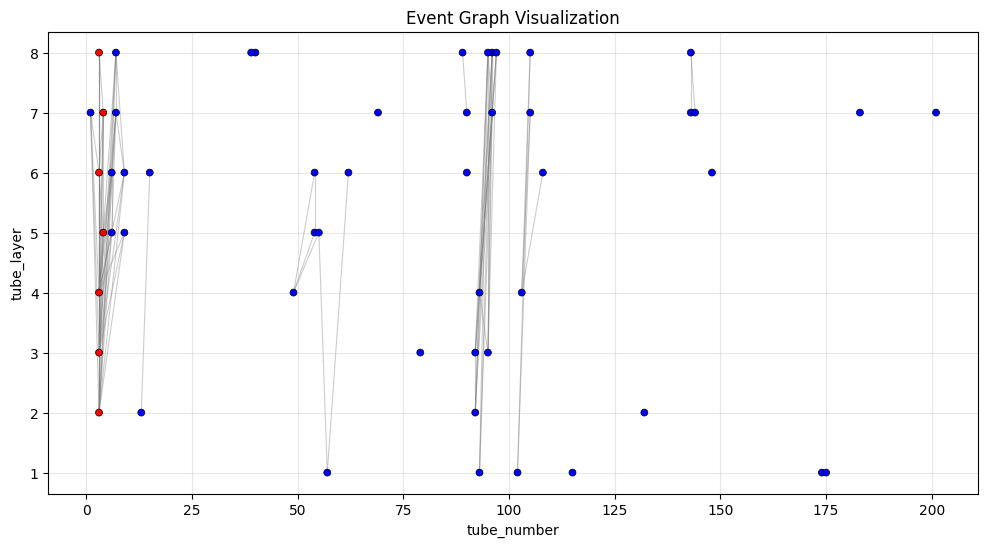

In [9]:
plot_event_graph(graphs_station_0[0])

In [7]:
import numpy as np
dummy_ids = np.linspace(1,10,10)
val_mask = dummy_ids%10 == 1
test_mask = dummy_ids%10 == 2
train_mask = ~(val_mask | test_mask)

In [8]:
train_mask

array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True])